In [49]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cmocean
from flow import sample_images
# jax is causing memory leaks for me
# from transforms_jax import radon
from transforms import radon
from utils import load_checkpoint
from torchdiffeq import odeint
import time
from torch import optim
from torchmetrics import CatMetric
from unet import Unet



In [50]:
torch.manual_seed(159753)
np.random.seed(159753)

torch.set_float32_matmul_precision('high')
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.enable_flash_sdp(True)
torch.backends.cuda.enable_mem_efficient_sdp(True)
torch.backends.cuda.enable_math_sdp(True)


In [51]:

%%capture
im_size = 128
problem = "shepp-logan"
n_sub = 4
n_full = 24
checkpoint_path = f'problems/interpolant/{problem}/{n_sub}-{n_full}-{im_size}x{im_size}/checkpoints/ckp_9513.tar'
device = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
# match the number of channels to your model
model = Unet(ch=32, ch_mul=[1, 2], att_channels=[0, 1]).to(device)

# ema_model = torch.optim.swa_utils.AveragedModel(
#     model, multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(0.9999)
# )
_, _, model, _, _, _= load_checkpoint(model=model, path=checkpoint_path)
model.eval()

In [52]:
"""
        'full_meas': full_meas,
        'sub_meas': sub_meas
"""
from train_interpolant import get_indices


data = torch.load(f"data/shepp-logan-sparse-and-full-{n_sub}-{n_full}-{im_size}.pt")
test = data['test']

test_x = test['sub_meas'][0].unsqueeze(0).unsqueeze(0).to(device)
test_y = test['full_meas'][0].unsqueeze(0).unsqueeze(0).to(device)

x_pad = torch.zeros(test_y.shape, device=device)
indices = get_indices(n_sub, n_full)
x_pad[:, :, indices, :] = test_x
test_x = x_pad


t = torch.linspace(0, 1, 5).to(device)

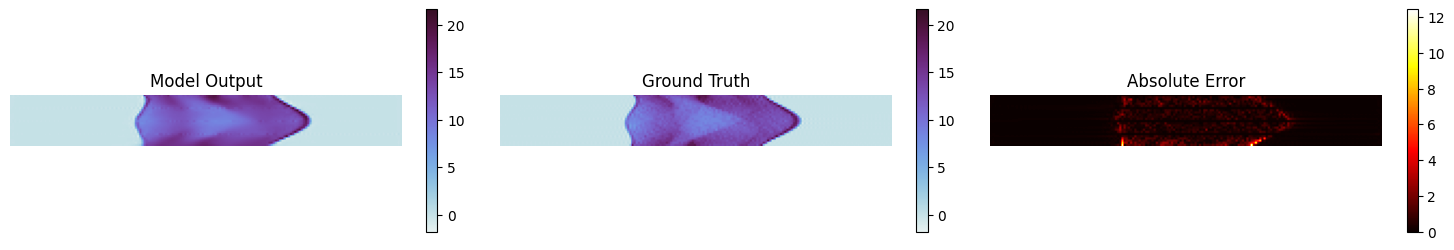

Output range: [-1.7609, 21.6193]
Ground truth range: [-1.2024, 20.7771]
Max absolute error: 12.4330
Mean absolute error: 0.2805


In [53]:
with torch.no_grad():
    output = odeint(
                func = lambda t, x: model(x, t.expand(x.shape[0])),
                t = t,
                y0 = test_x,
                method = 'euler',
                atol = 1e-5,
                rtol = 1e-5,
            )[-1].squeeze()
# Create subplot figure
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Convert tensors to numpy for plotting
output_np = output.cpu().detach().numpy()
test_y_np = test_y.cpu().squeeze().numpy()
error_np = torch.abs(test_y.cpu().squeeze() - output.cpu().detach()).numpy()

# Find common color scale for output and ground truth
vmin = min(output_np.min(), test_y_np.min())
vmax = max(output_np.max(), test_y_np.max())

# Plot output
im1 = axes[0].imshow(output_np, cmap=cmocean.cm.dense, vmin=vmin, vmax=vmax)
axes[0].set_title('Model Output')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], shrink=0.6)

# Plot ground truth
im2 = axes[1].imshow(test_y_np, cmap=cmocean.cm.dense, vmin=vmin, vmax=vmax)
axes[1].set_title('Ground Truth')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], shrink=0.6)

# Plot error (use separate scale for error)
im3 = axes[2].imshow(error_np, cmap='hot', vmin=0, vmax=error_np.max())
axes[2].set_title('Absolute Error')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], shrink=0.6)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"Output range: [{output_np.min():.4f}, {output_np.max():.4f}]")
print(f"Ground truth range: [{test_y_np.min():.4f}, {test_y_np.max():.4f}]")
print(f"Max absolute error: {error_np.max():.4f}")
print(f"Mean absolute error: {error_np.mean():.4f}")

In [54]:
# let's just quickly run the error calculations in the notebook, and save them
import os
save_path = f'problems/interpolant/{problem}/{n_sub}-{n_full}-{im_size}x{im_size}/errors'
os.makedirs(save_path, exist_ok=True)

test_data = torch.load(f"data/shepp-logan-sparse-and-full-{n_sub}-{n_full}-{im_size}.pt")['test']
test_x = test_data['sub_meas'].to(device)
test_y = test_data['full_meas'].to(device)

test_x = test_x.unsqueeze(1)
test_y = test_y.unsqueeze(1)

In [55]:
from tqdm import tqdm

t = torch.linspace(0, 1, 5).to(device)
l2_rel_errors = []
l1_rel_errors = []

batch_size = 256  # Adjust based on your GPU memory
num_samples = test_x.shape[0]

for batch_start in tqdm(range(0, num_samples, batch_size), desc="Calculating errors"):
    batch_end = min(batch_start + batch_size, num_samples)
    batch_x = test_x[batch_start:batch_end]
    batch_y = test_y[batch_start:batch_end]
    
    # Prepare batch with padding
    x_pad_batch = torch.zeros(batch_y.shape, device=device)
    indices = get_indices(n_sub, n_full)
    x_pad_batch[:, :, indices, :] = batch_x
    
    with torch.no_grad():
        batch_output = odeint(
            func=lambda t, x: model(x, t.expand(x.shape[0])),
            t=t,
            y0=x_pad_batch,
            method='dopri5',
            atol=1e-5,
            rtol=1e-5,
        )[-1]  # Don't squeeze here to keep batch dimension
    # Vectorized error calculation for the entire batch
    batch_output_squeezed = batch_output.squeeze(1)  # Shape: (batch_size, height, width)
    batch_y_squeezed = batch_y.squeeze(1)            # Shape: (batch_size, height, width)
    
    # Calculate L2 errors for all samples in batch
    diff = batch_output_squeezed - batch_y_squeezed
    l2_norms_diff = torch.norm(diff.view(diff.shape[0], -1), dim=1)  # L2 norm over flattened images
    l2_norms_target = torch.norm(batch_y_squeezed.view(batch_y_squeezed.shape[0], -1), dim=1)
    batch_l2_errors = l2_norms_diff / l2_norms_target
    
    # Calculate L1 errors for all samples in batch  
    l1_norms_diff = torch.norm(diff.view(diff.shape[0], -1), p=1, dim=1)  # L1 norm over flattened images
    l1_norms_target = torch.norm(batch_y_squeezed.view(batch_y_squeezed.shape[0], -1), p=1, dim=1)
    batch_l1_errors = l1_norms_diff / l1_norms_target
    
    # Convert to lists and extend
    l2_rel_errors.extend(batch_l2_errors.cpu().tolist())
    l1_rel_errors.extend(batch_l1_errors.cpu().tolist())

print(f"Mean L2 relative error: {np.mean(l2_rel_errors):.6f}")
print(f"Mean L1 relative error: {np.mean(l1_rel_errors):.6f}")
print(f"Std L2 relative error: {np.std(l2_rel_errors):.6f}")
print(f"Std L1 relative error: {np.std(l1_rel_errors):.6f}")

Calculating errors: 100%|██████████| 8/8 [05:03<00:00, 37.88s/it]

Mean L2 relative error: 0.093723
Mean L1 relative error: 0.058733
Std L2 relative error: 0.018916
Std L1 relative error: 0.005057


In [56]:
# save as csv
import polars as pl
df = pl.DataFrame({
    "l2_rel_error": l2_rel_errors,
    "l1_rel_error": l1_rel_errors,
    "mean_l2_rel_error": np.mean(l2_rel_errors),
    "mean_l1_rel_error": np.mean(l1_rel_errors),
    "std_l2_rel_error": np.std(l2_rel_errors),
    "std_l1_rel_error": np.std(l1_rel_errors)
})
df.write_csv(f"{save_path}/errors.csv")